# 🧠 Generative AI for Image Reconstruction — NPPE Project

## ⚙️ 1. Imports and Environment Setup

In [1]:
import os, math, time, random, json, gc
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    def autocast(*args, **kwargs):
        return _autocast('cuda', *args, **kwargs)
    def GradScaler(*args, **kwargs):
        return _GradScaler('cuda', *args, **kwargs)
except Exception:
    from torch.cuda.amp import autocast, GradScaler

In [21]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Auto-discover the dataset root by locating train.csv
INPUT_ROOT = Path('/kaggle/input')
DATA_DIR = None
for d in INPUT_ROOT.rglob('train.csv'):
    DATA_DIR = d.parent; break
assert DATA_DIR is not None, 'train.csv was not found anywhere under /kaggle/input'
print(f'DATA_DIR = {DATA_DIR}')

TRAIN_CORRUPT_DIR = DATA_DIR / 'train_corrupt'
TRAIN_CLEAN_DIR   = DATA_DIR / 'train_clean'
TEST_CORRUPT_DIR  = DATA_DIR / 'test_corrupt'
TRAIN_CSV         = DATA_DIR / 'train.csv'
SAMPLE_SUB_CSV    = DATA_DIR / 'sample_submission.csv'

WORK = Path('/kaggle/working')
CKPT_DIR = WORK / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True, parents=True)

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB
DATA_DIR = /kaggle/input/competitions/image-reconstruction-under-corruption/Datasets


In [20]:
INFERENCE_ONLY = True
PRETRAINED_CKPT = Path('/kaggle/input/datasets/deepamdey/genai-nppe/checkpoints/stage2_best.pt')

if INFERENCE_ONLY:
    assert PRETRAINED_CKPT.exists(), f'Checkpoint missing: {PRETRAINED_CKPT}'
    print(f'INFERENCE_ONLY=True. Loading weights from {PRETRAINED_CKPT}')
else:
    print('INFERENCE_ONLY=False. Training will run from scratch.')

INFERENCE_ONLY=True. Loading weights from /kaggle/input/datasets/deepamdey/genai-nppe/checkpoints/stage2_best.pt


## 🛠️ 2. Experiment Configuration

In [22]:
CFG = dict(
    # Data
    val_size = 2000,            # size of held-out validation split
    batch_size = 128,
    num_workers = 4,

    # Model (NAFNet-small variant)
    width = 48,                 # base channel count
    enc_blks = [2, 2, 4, 8],    # NAF blocks per encoder stage
    middle_blk = 12,
    dec_blks = [2, 2, 2, 2],

    # Stage 1: combined L1 + MS-SSIM objective
    stage1_epochs = 80,
    stage1_lr = 2e-4,
    stage1_wd = 1e-4,
    stage1_warmup_frac = 0.03,
    ssim_weight = 0.2,

    # Stage 2: MSE-only fine-tune
    stage2_epochs = 10,
    stage2_lr = 1e-5,

    # Exponential moving average
    ema_decay = 0.999,

    # Misc
    grad_clip = 1.0,
    log_every = 50,     # in steps
    save_every = 5,     # in epochs

    # Mid-run submissions (to compare LB score against val MSE)
    intermediate_submit_epochs = [10, 30],  # dump a submission at these epochs
)

# Persist the config alongside the run for reproducibility
with open(WORK / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)
print(json.dumps(CFG, indent=2))

{
  "val_size": 2000,
  "batch_size": 128,
  "num_workers": 4,
  "width": 48,
  "enc_blks": [
    2,
    2,
    4,
    8
  ],
  "middle_blk": 12,
  "dec_blks": [
    2,
    2,
    2,
    2
  ],
  "stage1_epochs": 80,
  "stage1_lr": 0.0002,
  "stage1_wd": 0.0001,
  "stage1_warmup_frac": 0.03,
  "ssim_weight": 0.2,
  "stage2_epochs": 10,
  "stage2_lr": 1e-05,
  "ema_decay": 0.999,
  "grad_clip": 1.0,
  "log_every": 50,
  "save_every": 5,
  "intermediate_submit_epochs": [
    10,
    30
  ]
}


## 🗂️ 3. Dataset Pipeline

* Reads corrupt/clean pairs and returns float tensors scaled to [0, 1]. 
* Augmentation is kept light: horizontal flip, vertical flip, and 90° rotations — applied identically to both images in a pair.

In [23]:
def load_img_np(path):
    return np.array(Image.open(path).convert('RGB'), dtype=np.uint8)

class PairDataset(Dataset):
    """Yields (corrupt, clean) as float tensors in [0,1], shape (3, 32, 32)."""
    def __init__(self, df, corrupt_dir, clean_dir, augment=False):
        self.df = df.reset_index(drop=True)
        self.corrupt_dir = corrupt_dir
        self.clean_dir = clean_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        c = load_img_np(self.corrupt_dir / row['corrupt_filename'])
        t = load_img_np(self.clean_dir   / row['clean_filename'])

        if self.augment:
            # Same random transform is applied to BOTH corrupt and clean
            if random.random() < 0.5:
                c = c[:, ::-1, :].copy(); t = t[:, ::-1, :].copy()   # horizontal flip
            if random.random() < 0.5:
                c = c[::-1, :, :].copy(); t = t[::-1, :, :].copy()   # vertical flip
            k = random.randint(0, 3)
            if k > 0:
                c = np.rot90(c, k).copy(); t = np.rot90(t, k).copy()

        # HWC uint8  ->  CHW float in [0,1]
        c = torch.from_numpy(c).permute(2,0,1).float() / 255.0
        t = torch.from_numpy(t).permute(2,0,1).float() / 255.0
        return c, t

class TestDataset(Dataset):
    def __init__(self, ids, corrupt_dir):
        self.ids = ids
        self.corrupt_dir = corrupt_dir
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        c = load_img_np(self.corrupt_dir / f'{img_id}.png')
        c = torch.from_numpy(c).permute(2,0,1).float() / 255.0
        return img_id, c

# Deterministic train/val split
full_df = pd.read_csv(TRAIN_CSV)
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df   = full_df.iloc[:CFG['val_size']].reset_index(drop=True)
train_df = full_df.iloc[CFG['val_size']:].reset_index(drop=True)
print(f'Train: {len(train_df)}, Val: {len(val_df)}')

train_ds = PairDataset(train_df, TRAIN_CORRUPT_DIR, TRAIN_CLEAN_DIR, augment=True)
val_ds   = PairDataset(val_df,   TRAIN_CORRUPT_DIR, TRAIN_CLEAN_DIR, augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True, persistent_workers=True)

# Quick sanity check on a single sample
c, t = train_ds[0]
print(f'Sample shapes: corrupt={c.shape}, clean={t.shape}, dtype={c.dtype}')
print(f'Sample ranges: corrupt [{c.min():.3f}, {c.max():.3f}], clean [{t.min():.3f}, {t.max():.3f}]')

Train: 46000, Val: 2000
Sample shapes: corrupt=torch.Size([3, 32, 32]), clean=torch.Size([3, 32, 32]), dtype=torch.float32
Sample ranges: corrupt [0.000, 0.773], clean [0.004, 1.000]


## 🧩 4. Model Architecture (NAFNet)

In [24]:
class LayerNorm2d(nn.Module):
    def __init__(self, c, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(c))
        self.bias   = nn.Parameter(torch.zeros(c))
        self.eps = eps
    def forward(self, x):
        mu  = x.mean(1, keepdim=True)
        var = x.var(1, keepdim=True, unbiased=False)
        x = (x - mu) / torch.sqrt(var + self.eps)
        return x * self.weight.view(1,-1,1,1) + self.bias.view(1,-1,1,1)

class SimpleGate(nn.Module):
    def forward(self, x):
        a, b = x.chunk(2, dim=1)
        return a * b

class NAFBlock(nn.Module):
    def __init__(self, c, dw_expand=2, ffn_expand=2, drop=0.0):
        super().__init__()
        dw_c = c * dw_expand
        self.norm1 = LayerNorm2d(c)
        self.conv1 = nn.Conv2d(c, dw_c, 1)
        self.conv2 = nn.Conv2d(dw_c, dw_c, 3, padding=1, groups=dw_c)
        self.sg    = SimpleGate()
        # Lightweight channel attention
        self.sca   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(dw_c // 2, dw_c // 2, 1)
        )
        self.conv3 = nn.Conv2d(dw_c // 2, c, 1)

        ffn_c = c * ffn_expand
        self.norm2 = LayerNorm2d(c)
        self.conv4 = nn.Conv2d(c, ffn_c, 1)
        self.conv5 = nn.Conv2d(ffn_c // 2, c, 1)

        self.beta  = nn.Parameter(torch.zeros(1, c, 1, 1))
        self.gamma = nn.Parameter(torch.zeros(1, c, 1, 1))
        self.drop = nn.Dropout(drop) if drop > 0 else nn.Identity()

    def forward(self, x):
        # First sub-block
        y = self.norm1(x)
        y = self.conv1(y)
        y = self.conv2(y)
        y = self.sg(y)
        y = y * self.sca(y)
        y = self.conv3(y)
        y = self.drop(y)
        x = x + y * self.beta

        # Second sub-block (FFN-style)
        y = self.norm2(x)
        y = self.conv4(y)
        y = self.sg(y)
        y = self.conv5(y)
        y = self.drop(y)
        x = x + y * self.gamma
        return x

class NAFNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, width=48, enc_blks=(2,2,4,8), middle_blk=12, dec_blks=(2,2,2,2)):
        super().__init__()
        self.intro  = nn.Conv2d(in_ch, width, 3, padding=1)
        self.ending = nn.Conv2d(width, out_ch, 3, padding=1)
        self.encoders = nn.ModuleList()
        self.downs    = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.ups      = nn.ModuleList()
        chan = width
        for n in enc_blks:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
            self.downs.append(nn.Conv2d(chan, 2*chan, 2, stride=2))
            chan *= 2
        self.middle = nn.Sequential(*[NAFBlock(chan) for _ in range(middle_blk)])
        for n in dec_blks:
            self.ups.append(nn.Sequential(nn.Conv2d(chan, 2*chan, 1, bias=False), nn.PixelShuffle(2)))
            chan //= 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
        self.padder_size = 2 ** len(enc_blks)  # 4 downsamples -> input H, W must be multiples of 16

    def check_and_pad(self, x):
        _, _, h, w = x.shape
        ph = (self.padder_size - h % self.padder_size) % self.padder_size
        pw = (self.padder_size - w % self.padder_size) % self.padder_size
        x = F.pad(x, (0, pw, 0, ph))
        return x, h, w

    def forward(self, inp):
        B, C, H, W = inp.shape
        x, h0, w0 = self.check_and_pad(inp)
        x = self.intro(x)
        skips = []
        for enc, down in zip(self.encoders, self.downs):
            x = enc(x); skips.append(x); x = down(x)
        x = self.middle(x)
        for up, dec, sk in zip(self.ups, self.decoders, skips[::-1]):
            x = up(x); x = x + sk; x = dec(x)
        x = self.ending(x)
        x = x[:, :, :h0, :w0]
        # Residual formulation: network predicts a delta to be added to the input
        return inp + x

# Build the model and verify the forward pass
model = NAFNet(width=CFG['width'], enc_blks=CFG['enc_blks'],
               middle_blk=CFG['middle_blk'], dec_blks=CFG['dec_blks']).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Model params: {n_params:.2f}M')

# 32 is divisible by 16, so no padding should be required for CIFAR inputs
with torch.no_grad():
    dummy = torch.randn(2, 3, 32, 32).to(DEVICE)
    out = model(dummy)
    print(f'Forward ok: {dummy.shape} -> {out.shape}')

Model params: 65.36M
Forward ok: torch.Size([2, 3, 32, 32]) -> torch.Size([2, 3, 32, 32])


## 📉 5. Loss Functions & Optimization Strategy

In [25]:
# --- MS-SSIM (self-contained so we don't pull in another package) ---
def _gaussian_window(window_size=11, sigma=1.5, channels=3):
    coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    g = (g / g.sum()).unsqueeze(0)
    window = (g.t() @ g).unsqueeze(0).unsqueeze(0)  # shape (1, 1, W, W)
    window = window.expand(channels, 1, window_size, window_size).contiguous()
    return window

_SSIM_WINDOW = None
def ssim(x, y, window_size=11, channels=3, val_range=1.0):
    global _SSIM_WINDOW
    if _SSIM_WINDOW is None or _SSIM_WINDOW.device != x.device:
        _SSIM_WINDOW = _gaussian_window(window_size, 1.5, channels).to(x.device)
    w = _SSIM_WINDOW
    mu_x = F.conv2d(x, w, padding=window_size//2, groups=channels)
    mu_y = F.conv2d(y, w, padding=window_size//2, groups=channels)
    mu_x2, mu_y2, mu_xy = mu_x*mu_x, mu_y*mu_y, mu_x*mu_y
    sigma_x2 = F.conv2d(x*x, w, padding=window_size//2, groups=channels) - mu_x2
    sigma_y2 = F.conv2d(y*y, w, padding=window_size//2, groups=channels) - mu_y2
    sigma_xy = F.conv2d(x*y, w, padding=window_size//2, groups=channels) - mu_xy
    C1 = (0.01 * val_range) ** 2
    C2 = (0.03 * val_range) ** 2
    ssim_map = ((2*mu_xy + C1) * (2*sigma_xy + C2)) / ((mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2))
    cs_map   = (2*sigma_xy + C2) / (sigma_x2 + sigma_y2 + C2)
    return ssim_map.mean(dim=[1,2,3]), cs_map.mean(dim=[1,2,3])

def ms_ssim_loss(x, y):
    """MS-SSIM loss tailored for 32x32 inputs, hardened against NaNs.

    - Runs in fp32 to dodge AMP numerical issues.
    - Clamps inputs to [0, 1] so the SSIM statistics stay well defined.
    - Takes abs() of cs values before exponentiation (no NaN from negative bases).
    - Falls back to 0 loss if anything degenerates so training doesn't blow up.
    """
    x = x.float().clamp(0, 1)
    y = y.float().clamp(0, 1)
    weights = torch.tensor([0.25, 0.35, 0.40], device=x.device, dtype=torch.float32)
    msssim_val = torch.ones([], device=x.device, dtype=torch.float32)
    for i in range(len(weights) - 1):
        _, cs = ssim(x, y)
        cs_m = cs.mean().abs().clamp(min=1e-4)
        msssim_val = msssim_val * (cs_m ** weights[i])
        x = F.avg_pool2d(x, kernel_size=2)
        y = F.avg_pool2d(y, kernel_size=2)
    s, _ = ssim(x, y)
    s_m = s.mean().abs().clamp(min=1e-4)
    msssim_val = msssim_val * (s_m ** weights[-1])
    loss = 1.0 - msssim_val
    # Fallback: if the loss became non-finite, return 0 so L1 alone keeps training going
    if not torch.isfinite(loss):
        return torch.zeros([], device=x.device, dtype=torch.float32)
    return loss

# --- Exponential Moving Average of weights ---
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items() if v.dtype.is_floating_point}
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
    def apply_to(self, model):
        """Return a fresh copy of the model loaded with EMA weights; original is untouched."""
        cp = deepcopy(model)
        sd = cp.state_dict()
        for k in self.shadow:
            sd[k] = self.shadow[k].clone()
        cp.load_state_dict(sd)
        return cp

print('Losses and EMA ready.')

Losses and EMA ready.


## 🧰 6. Training Utilities & Evaluation Metrics

In [26]:
@torch.no_grad()
def evaluate(model, loader, device=DEVICE):
    model.eval()
    total_sq, total_n = 0.0, 0
    for c, t in loader:
        c, t = c.to(device, non_blocking=True), t.to(device, non_blocking=True)
        with autocast():
            pred = model(c).clamp(0, 1)
        # Rescale to [0, 255] so MSE aligns with the leaderboard scale
        diff = (pred.float() - t.float()) * 255.0
        total_sq += (diff ** 2).sum().item()
        total_n  += diff.numel()
    return total_sq / total_n

def cosine_lr_with_warmup(step, total_steps, base_lr, min_lr=1e-6, warmup_frac=0.03):
    warmup_steps = int(total_steps * warmup_frac)
    if step < warmup_steps:
        return base_lr * (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))

def save_ckpt(path, model, ema, optim, epoch, best_mse):
    torch.save({
        'model':  model.state_dict(),
        'ema':    ema.shadow,
        'optim':  optim.state_dict(),
        'epoch':  epoch,
        'best_mse': best_mse,
    }, path)

print('Training helpers ready.')

Training helpers ready.


## 📤 6b. Intermediate Submission & Progress Tracking

In [27]:
# Build the test loader once and reuse it
_sub_df_template = pd.read_csv(SAMPLE_SUB_CSV)
_test_ids_global = _sub_df_template['id'].tolist()
_test_ds_global = TestDataset(_test_ids_global, TEST_CORRUPT_DIR)
_test_loader_global = DataLoader(_test_ds_global, batch_size=256, shuffle=False,
                                  num_workers=CFG['num_workers'], pin_memory=True)
print(f'Pre-built test loader: {len(_test_ids_global)} images')

@torch.no_grad()
def make_submission(model, out_name, use_tta=False):
    model.eval()
    preds_buf = np.empty((len(_test_ids_global), 3072), dtype=np.float32)
    ids_out = []
    offset = 0
    t0 = time.time()
    for img_ids, c in _test_loader_global:
        c = c.to(DEVICE, non_blocking=True)
        if use_tta:
            y = predict_tta(model, c)
        else:
            with autocast():
                y = model(c).clamp(0, 1).float()
        y = (y * 255.0).clamp(0, 255).cpu().numpy()
        y_hwc = y.transpose(0, 2, 3, 1).reshape(y.shape[0], -1)
        bs = y_hwc.shape[0]
        preds_buf[offset:offset+bs] = y_hwc
        ids_out.extend(list(img_ids))
        offset += bs
    assert ids_out == _test_ids_global, 'Order mismatch'
    pixel_cols = [f'pixel_{i}' for i in range(3072)]
    out = pd.DataFrame(preds_buf, columns=pixel_cols)
    out.insert(0, 'id', ids_out)
    out_path = WORK / out_name
    out.to_csv(out_path, index=False)
    print(f'   [submission] {out_name}  shape={out.shape}  range=[{preds_buf.min():.1f},{preds_buf.max():.1f}]  {time.time()-t0:.1f}s')
    return out_path

print('make_submission() ready.')

Pre-built test loader: 12000 images
make_submission() ready.


## 🚀 7. Stage 1 Training — Hybrid Loss Optimization

In [28]:
if INFERENCE_ONLY:
    print('[INFERENCE_ONLY] Skipping Stage 1 training')
else:
    model = NAFNet(width=CFG['width'], enc_blks=CFG['enc_blks'],
                   middle_blk=CFG['middle_blk'], dec_blks=CFG['dec_blks']).to(DEVICE)
    ema = EMA(model, decay=CFG['ema_decay'])
    
    optim = torch.optim.AdamW(model.parameters(), lr=CFG['stage1_lr'], weight_decay=CFG['stage1_wd'], betas=(0.9, 0.95))
    scaler = GradScaler()
    
    steps_per_epoch = len(train_loader)
    total_steps = steps_per_epoch * CFG['stage1_epochs']
    print(f'Stage 1: {CFG["stage1_epochs"]} epochs × {steps_per_epoch} steps = {total_steps} total steps')
    
    # ---- RESUME HANDLING ----
    # Pick up from stage1_last.pt if it's lying around from a previous run.
    resume_path = CKPT_DIR / 'stage1_last.pt'
    start_epoch = 1
    best_val_mse = float('inf')
    history = []
    global_step = 0
    
    if resume_path.exists():
        print(f'\n>>> RESUMING from {resume_path}')
        ck = torch.load(resume_path, map_location=DEVICE)
        model.load_state_dict(ck['model'])
        # Reload EMA shadow tensors
        ema.shadow = {k: v.to(DEVICE) for k, v in ck['ema'].items()}
        optim.load_state_dict(ck['optim'])
        start_epoch = ck['epoch'] + 1
        best_val_mse = ck.get('best_mse', float('inf'))
        global_step = (start_epoch - 1) * steps_per_epoch
        print(f'   Resumed at epoch {start_epoch}, best_val_mse so far = {best_val_mse:.2f}')
        # Reload history log if it was persisted
        hist_path = WORK / 'stage1_history.csv'
        if hist_path.exists():
            history = pd.read_csv(hist_path).to_dict('records')
            print(f'   Restored {len(history)} history rows')
    else:
        print('\n>>> Starting stage 1 from scratch (no checkpoint found)')
    
    stage1_t0 = time.time()
    
    for epoch in range(start_epoch, CFG['stage1_epochs'] + 1):
        model.train()
        epoch_t0 = time.time()
        run_loss, run_l1, run_ssim, run_n = 0.0, 0.0, 0.0, 0
    
        for c, t in train_loader:
            # Update learning rate (cosine with warmup)
            lr = cosine_lr_with_warmup(global_step, total_steps, CFG['stage1_lr'],
                                        min_lr=1e-6, warmup_frac=CFG['stage1_warmup_frac'])
            for pg in optim.param_groups: pg['lr'] = lr
    
            c = c.to(DEVICE, non_blocking=True)
            t = t.to(DEVICE, non_blocking=True)
    
            optim.zero_grad(set_to_none=True)
            with autocast():
                pred = model(c)
                loss_l1 = F.l1_loss(pred, t)
            # SSIM loss runs OUTSIDE autocast (fp32) — AMP isn't safe for it
            loss_ssim = ms_ssim_loss(pred.float(), t.float())
            loss = loss_l1 + CFG['ssim_weight'] * loss_ssim
    
            # NaN safeguard: drop the batch entirely if loss went non-finite
            if not torch.isfinite(loss):
                print(f'   [WARN] non-finite loss at step {global_step}, skipping batch')
                global_step += 1
                continue
    
            scaler.scale(loss).backward()
            scaler.unscale_(optim)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(optim)
            scaler.update()
            ema.update(model)
    
            bs = c.size(0)
            run_loss += loss.item() * bs
            run_l1   += loss_l1.item() * bs
            run_ssim += loss_ssim.item() * bs
            run_n    += bs
            global_step += 1
    
            if global_step % CFG['log_every'] == 0:
                print(f'  ep{epoch} step{global_step}/{total_steps}  lr={lr:.2e}  loss={loss.item():.4f}  l1={loss_l1.item():.4f}  ssim={loss_ssim.item():.4f}')
    
        # Epoch done — evaluate with EMA weights
        ema_model = ema.apply_to(model)
        val_mse = evaluate(ema_model, val_loader)
        del ema_model; gc.collect(); torch.cuda.empty_cache()
    
        elapsed = time.time() - epoch_t0
        total_elapsed = (time.time() - stage1_t0) / 3600
        print(f'[Ep {epoch:3d}] train_loss={run_loss/run_n:.4f}  l1={run_l1/run_n:.4f}  ssim={run_ssim/run_n:.4f}  | val_MSE(0-255)={val_mse:.2f}  | {elapsed:.0f}s/epoch  | total {total_elapsed:.2f}h')
    
        history.append(dict(epoch=epoch, loss=run_loss/run_n, val_mse=val_mse, lr=lr, time_s=elapsed))
    
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            save_ckpt(CKPT_DIR / 'stage1_best.pt', model, ema, optim, epoch, best_val_mse)
            print(f'   -> NEW BEST  val_MSE={val_mse:.2f}  (saved)')
    
        # Mid-run LB check: write a submission at selected epochs so we can manually upload
        # to Kaggle and see how the LB MSE tracks the val MSE
        if epoch in CFG.get('intermediate_submit_epochs', []):
            print(f'   [mid-run check] generating intermediate submission at epoch {epoch}...')
            ema_model = ema.apply_to(model)
            out_path = make_submission(ema_model, f'submission_epoch{epoch:03d}.csv', use_tta=False)
            del ema_model; gc.collect(); torch.cuda.empty_cache()
            print(f'   [mid-run check] val_MSE(0-255)={val_mse:.2f}  --> download {out_path.name} and submit to Kaggle to check LB gap')
    
        # Save a "last" checkpoint every epoch so resume is always cheap (~100 MB file)
        save_ckpt(CKPT_DIR / 'stage1_last.pt', model, ema, optim, epoch, best_val_mse)
        # Write history incrementally too, so a resume can pick it back up
        pd.DataFrame(history).to_csv(WORK / 'stage1_history.csv', index=False)
    
    # One final save at the very end
    save_ckpt(CKPT_DIR / 'stage1_last.pt', model, ema, optim, CFG['stage1_epochs'], best_val_mse)
    pd.DataFrame(history).to_csv(WORK / 'stage1_history.csv', index=False)
    print(f'\nStage 1 done. Best val MSE: {best_val_mse:.2f}')
    print(f'Total stage 1 time: {(time.time() - stage1_t0) / 3600:.2f}h')

[INFERENCE_ONLY] Skipping Stage 1 training


## 🎯 8. Stage 2 Fine-Tuning — MSE Optimization
Pick up the EMA weights from stage 1, then fine-tune at a tiny learning rate on MSE only for 10 epochs. This directly optimizes the leaderboard metric and typically buys another small drop in val MSE.

In [29]:
if INFERENCE_ONLY:
    import shutil
    shutil.copy(PRETRAINED_CKPT, CKPT_DIR / 'stage2_best.pt')
    print(f'[INFERENCE_ONLY] Copied pretrained stage2_best.pt to {CKPT_DIR}')
else:
    ckpt = torch.load(CKPT_DIR / 'stage1_best.pt', map_location=DEVICE)
    model = NAFNet(width=CFG['width'], enc_blks=CFG['enc_blks'],
                   middle_blk=CFG['middle_blk'], dec_blks=CFG['dec_blks']).to(DEVICE)
    # Write EMA tensors back into the live model
    sd = model.state_dict()
    for k, v in ckpt['ema'].items():
        sd[k] = v
    model.load_state_dict(sd)
    print(f'Loaded EMA weights from stage 1 (best val MSE was {ckpt["best_mse"]:.2f})')
    
    # Quick validation check before fine-tuning
    val_mse_pre = evaluate(model, val_loader)
    print(f'Pre-finetune val MSE: {val_mse_pre:.2f}')
    
    # New EMA tracker for stage 2
    ema2 = EMA(model, decay=CFG['ema_decay'])
    optim2 = torch.optim.AdamW(model.parameters(), lr=CFG['stage2_lr'], weight_decay=0.0)
    scaler2 = GradScaler()
    
    # ---- STAGE 2 RESUME HANDLING ----
    s2_last_path = CKPT_DIR / 'stage2_last.pt'
    s2_start_epoch = 1
    best2 = val_mse_pre
    
    if s2_last_path.exists():
        print(f'\n>>> RESUMING stage 2 from {s2_last_path}')
        ck2 = torch.load(s2_last_path, map_location=DEVICE)
        model.load_state_dict(ck2['model'])
        ema2.shadow = {k: v.to(DEVICE) for k, v in ck2['ema'].items()}
        optim2.load_state_dict(ck2['optim'])
        s2_start_epoch = ck2['epoch'] + 1
        best2 = ck2.get('best_mse', val_mse_pre)
        print(f'   Resumed stage 2 at epoch {s2_start_epoch}, best_val_mse={best2:.2f}')
    else:
        # Store the pre-finetune score as the baseline best so we never regress
        save_ckpt(CKPT_DIR / 'stage2_best.pt', model, ema2, optim2, 0, best2)
        print('\n>>> Starting stage 2 from scratch')
    
    steps_per_epoch = len(train_loader)
    total_steps2 = steps_per_epoch * CFG['stage2_epochs']
    
    stage2_t0 = time.time()
    global_step2 = (s2_start_epoch - 1) * steps_per_epoch
    for epoch in range(s2_start_epoch, CFG['stage2_epochs'] + 1):
        model.train()
        epoch_t0 = time.time()
        run_loss, run_n = 0.0, 0
    
        for c, t in train_loader:
            lr = cosine_lr_with_warmup(global_step2, total_steps2, CFG['stage2_lr'], min_lr=1e-7, warmup_frac=0.05)
            for pg in optim2.param_groups: pg['lr'] = lr
    
            c = c.to(DEVICE, non_blocking=True)
            t = t.to(DEVICE, non_blocking=True)
    
            optim2.zero_grad(set_to_none=True)
            with autocast():
                pred = model(c)
                loss = F.mse_loss(pred, t)
    
            if not torch.isfinite(loss):
                print(f'   [WARN] non-finite loss at stage2 step {global_step2}, skipping')
                global_step2 += 1
                continue
    
            scaler2.scale(loss).backward()
            scaler2.unscale_(optim2)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler2.step(optim2)
            scaler2.update()
            ema2.update(model)
    
            bs = c.size(0)
            run_loss += loss.item() * bs
            run_n += bs
            global_step2 += 1
    
        # Evaluate with EMA
        ema_model = ema2.apply_to(model)
        val_mse = evaluate(ema_model, val_loader)
        del ema_model; gc.collect(); torch.cuda.empty_cache()
    
        elapsed = time.time() - epoch_t0
        print(f'[S2 ep {epoch}] train_mse={run_loss/run_n:.6f}  val_MSE(0-255)={val_mse:.2f}  lr={lr:.2e}  {elapsed:.0f}s')
    
        if val_mse < best2:
            best2 = val_mse
            save_ckpt(CKPT_DIR / 'stage2_best.pt', model, ema2, optim2, epoch, best2)
            print(f'   -> STAGE 2 NEW BEST  val_MSE={val_mse:.2f}  (saved)')
    
        # "Last" checkpoint every epoch for robust resume
        save_ckpt(CKPT_DIR / 'stage2_last.pt', model, ema2, optim2, epoch, best2)
    
    print(f'\nStage 2 done. Best val MSE overall: {best2:.2f}')
    print(f'Total stage 2 time: {(time.time() - stage2_t0) / 60:.1f} min')

[INFERENCE_ONLY] Copied pretrained stage2_best.pt to /kaggle/working/checkpoints


## 🔍 9. Inference with Test-Time Augmentation (TTA)

TTA variants: identity, h-flip, v-flip, h+v flip, 90°, 180°, 270°, and 90°+h-flip. Each branch's output is inverted back to the original orientation and all 8 predictions are averaged.

In [30]:
# Load the best stage-2 checkpoint (EMA weights inside)
best_ckpt_path = CKPT_DIR / 'stage2_best.pt' if (CKPT_DIR / 'stage2_best.pt').exists() else CKPT_DIR / 'stage1_best.pt'
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
final_model = NAFNet(width=CFG['width'], enc_blks=CFG['enc_blks'],
                     middle_blk=CFG['middle_blk'], dec_blks=CFG['dec_blks']).to(DEVICE)
sd = final_model.state_dict()
for k, v in ckpt['ema'].items():
    sd[k] = v
final_model.load_state_dict(sd)
final_model.eval()
print(f'Loaded {best_ckpt_path.name} (best val MSE: {ckpt["best_mse"]:.2f})')

# --- 8 TTA transforms expressed as (forward, inverse) pairs ---
def tta_forward_inverse():
    # input tensor is (B, C, H, W)
    fwd_inv = [
        (lambda x: x,                          lambda y: y),                           # identity
        (lambda x: torch.flip(x, dims=[3]),    lambda y: torch.flip(y, dims=[3])),     # h-flip
        (lambda x: torch.flip(x, dims=[2]),    lambda y: torch.flip(y, dims=[2])),     # v-flip
        (lambda x: torch.flip(x, dims=[2,3]),  lambda y: torch.flip(y, dims=[2,3])),   # h+v flip (equivalent to rot180)
        (lambda x: torch.rot90(x, 1, [2,3]),   lambda y: torch.rot90(y, -1, [2,3])),   # rot 90
        (lambda x: torch.rot90(x, 2, [2,3]),   lambda y: torch.rot90(y, -2, [2,3])),   # rot 180
        (lambda x: torch.rot90(x, 3, [2,3]),   lambda y: torch.rot90(y, -3, [2,3])),   # rot 270
        (lambda x: torch.flip(torch.rot90(x,1,[2,3]), dims=[3]),
         lambda y: torch.rot90(torch.flip(y, dims=[3]), -1, [2,3])),                   # rot90 + h-flip
    ]
    return fwd_inv

@torch.no_grad()
def predict_tta(model, x):
    outs = []
    for fwd, inv in tta_forward_inverse():
        xt = fwd(x)
        with autocast():
            yt = model(xt).clamp(0, 1)
        yo = inv(yt.float())
        outs.append(yo)
    return torch.stack(outs, dim=0).mean(dim=0).clamp(0, 1)

# --- Quantify the TTA gain on the validation set ---
print('Measuring TTA effect on validation...')
total_sq_notta, total_sq_tta, total_n = 0.0, 0.0, 0
for c, t in val_loader:
    c, t = c.to(DEVICE), t.to(DEVICE)
    with torch.no_grad():
        with autocast():
            no_tta = final_model(c).clamp(0,1).float()
        tta = predict_tta(final_model, c)
    diff_n = (no_tta - t) * 255.0
    diff_t = (tta     - t) * 255.0
    total_sq_notta += (diff_n**2).sum().item()
    total_sq_tta   += (diff_t**2).sum().item()
    total_n += diff_n.numel()
print(f'Val MSE no TTA: {total_sq_notta/total_n:.2f}')
print(f'Val MSE 8x TTA: {total_sq_tta/total_n:.2f}')
print(f'Improvement from TTA: {(total_sq_notta - total_sq_tta)/total_n:.2f}')

Loaded stage2_best.pt (best val MSE: 1078.05)
Measuring TTA effect on validation...
Val MSE no TTA: 1078.05
Val MSE 8x TTA: 1006.36
Improvement from TTA: 71.69


## 📝 10. Test Inference & Submission Generation

In [31]:
sub_df = pd.read_csv(SAMPLE_SUB_CSV)
test_ids = sub_df['id'].tolist()
print(f'Test images: {len(test_ids)}')

test_ds = TestDataset(test_ids, TEST_CORRUPT_DIR)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False,
                         num_workers=CFG['num_workers'], pin_memory=True)

preds = np.empty((len(test_ids), 3072), dtype=np.float32)
ids_out = []
offset = 0

t0 = time.time()
for img_ids, c in test_loader:
    c = c.to(DEVICE, non_blocking=True)
    y = predict_tta(final_model, c)
    y = (y * 255.0).clamp(0, 255).cpu().numpy()   # (B, 3, 32, 32) in [0, 255] floats
    y_hwc = y.transpose(0, 2, 3, 1).reshape(y.shape[0], -1)  # (B, 3072) in HWC order
    bs = y_hwc.shape[0]
    preds[offset:offset+bs] = y_hwc
    ids_out.extend(list(img_ids))
    offset += bs
print(f'Inference time: {time.time() - t0:.1f}s')

# Confirm row order exactly matches sample_submission
assert ids_out == test_ids, 'Order mismatch between sample_submission and test loader'
print('Order matches sample_submission ✓')

# --- Sanity check vs baseline: identity would just echo the input pixels back.
# Compare one test image to confirm the pixel layout is right.
raw0 = load_img_np(TEST_CORRUPT_DIR / f'{test_ids[0]}.png')  # HWC uint8
flat_hwc = raw0.flatten().astype(np.float32)
sample_row = sub_df.iloc[0, 1:].values.astype(np.float32)
print(f'Sample row from sample_submission (first 10): {sample_row[:10]}')
print(f'Identity HWC flatten of test_00000 (first 10): {flat_hwc[:10]}')
print(f'Match (HWC order is correct): {np.allclose(flat_hwc, sample_row)}')

# Assemble the submission DataFrame
pixel_cols = [f'pixel_{i}' for i in range(3072)]
sub_out = pd.DataFrame(preds, columns=pixel_cols)
sub_out.insert(0, 'id', ids_out)

out_path = WORK / 'submission.csv'
sub_out.to_csv(out_path, index=False)
print(f'\nSubmission saved to: {out_path}')
print(f'Shape: {sub_out.shape}')
print(f'Value range: [{preds.min():.2f}, {preds.max():.2f}]  mean={preds.mean():.2f}')

Test images: 12000
Inference time: 61.4s
Order matches sample_submission ✓
Sample row from sample_submission (first 10): [ 5.  5.  5. 14. 14. 13. 26. 26. 25. 36.]
Identity HWC flatten of test_00000 (first 10): [ 5.  5.  5. 14. 14. 13. 26. 26. 25. 36.]
Match (HWC order is correct): True

Submission saved to: /kaggle/working/submission.csv
Shape: (12000, 3073)
Value range: [0.00, 255.00]  mean=121.11


## 🖼️ 11. Visual Validation & Result Inspection

Before uploading, glance at a handful of predicted vs. corrupt test images to confirm the model is doing reasonable restoration.

/tmp/ipykernel_55/3153338562.py:25: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3153338562.py:26: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/prediction_samples.png', dpi=100, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


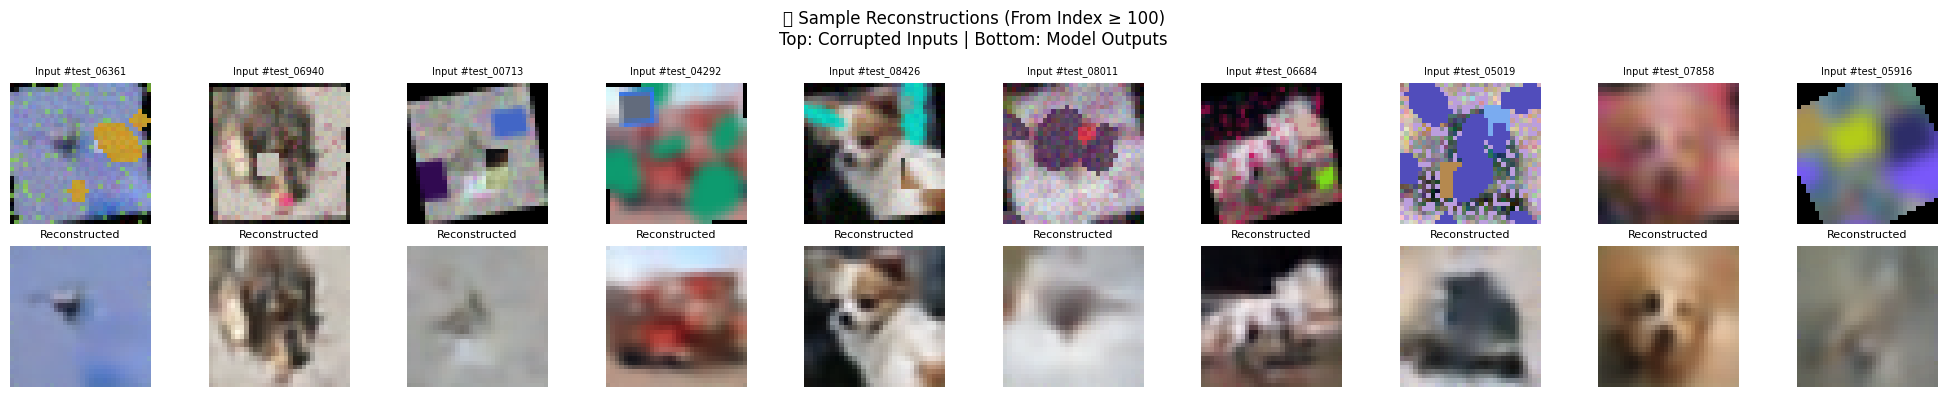

In [32]:
import random as rnd
rnd.seed(0)

# sample 10 indices starting from 100
sample_idx = rnd.sample(range(50, len(test_ids)), 10)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for j, i in enumerate(sample_idx):
    c_img = load_img_np(TEST_CORRUPT_DIR / f'{test_ids[i]}.png')
    pred_flat = preds[i]
    pred_img = pred_flat.reshape(32, 32, 3).clip(0, 255).astype(np.uint8)

    axes[0, j].imshow(c_img)
    axes[0, j].axis('off')
    axes[0, j].set_title(f'Input #{test_ids[i]}', fontsize=7)

    axes[1, j].imshow(pred_img)
    axes[1, j].axis('off')
    axes[1, j].set_title('Reconstructed', fontsize=8)

# updated title
plt.suptitle('🔍 Sample Reconstructions (From Index ≥ 100)\nTop: Corrupted Inputs | Bottom: Model Outputs', fontsize=12)

plt.tight_layout()
plt.savefig('/kaggle/working/prediction_samples.png', dpi=100, bbox_inches='tight')
plt.show()